### DAPT: stance classification

The extrinsic check: frozen-probe and fine-tuned macro-F1 for vanilla vs
adapted RoBERTa-large, identical fine-tuning recipe throughout.

Reads `results.csv` from Drive, writes `dapt_f1.png`.

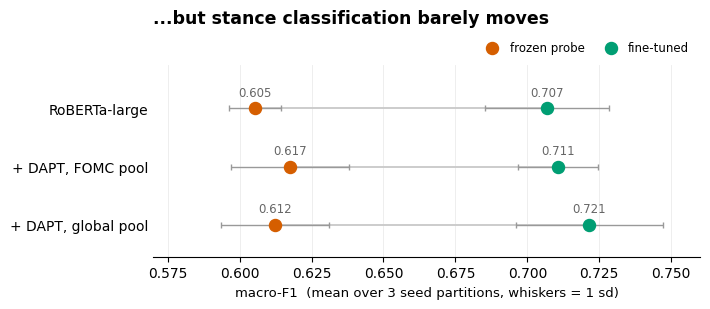

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import polars as pl

d = pl.read_csv(RESULTS_DIR / "results.csv").filter(pl.col("corpus") == "twd")

ROWS = [
    ("RoBERTa-large", "roberta-large", "frozen:roberta-large"),
    ("+ DAPT, FOMC pool", "dapt-fomc:roberta-large", "frozen-dapt-fomc:roberta-large"),
    (
        "+ DAPT, global pool",
        "dapt-global:roberta-large",
        "frozen-dapt-global:roberta-large",
    ),
]
FROZ, FINE = "#D55E00", "#009E73"


def stats(model):
    v = d.filter(pl.col("model") == model)["macro_f1"]
    return v.mean(), v.std()


fig, ax = plt.subplots(figsize=(7.2, 3.2))

for i, (label, ft, fz) in enumerate(ROWS):
    y = len(ROWS) - 1 - i
    fzm, fzs = stats(fz)
    ftm, fts = stats(ft)
    ax.plot([fzm, ftm], [y, y], color="#ccc", lw=1.4, zorder=1, solid_capstyle="round")
    ax.errorbar(
        [fzm, ftm],
        [y, y],
        xerr=[fzs, fts],
        fmt="none",
        ecolor="#999",
        elinewidth=1,
        capsize=2.5,
        zorder=2,
    )
    ax.scatter(fzm, y, s=75, color=FROZ, zorder=3)
    ax.scatter(ftm, y, s=75, color=FINE, zorder=3)
    ax.text(fzm, y + 0.22, f"{fzm:.3f}", ha="center", fontsize=8.5, color="#666")
    ax.text(ftm, y + 0.22, f"{ftm:.3f}", ha="center", fontsize=8.5, color="#666")

ax.set_yticks(range(len(ROWS)))
ax.set_yticklabels([r[0] for r in reversed(ROWS)], fontsize=10)
ax.set_ylim(-0.55, len(ROWS) - 0.25)
ax.set_xlim(0.57, 0.76)
ax.set_xlabel("macro-F1  (mean over 3 seed partitions, whiskers = 1 sd)", fontsize=9.5)

ax.scatter([], [], s=75, color=FROZ, label="frozen probe")
ax.scatter([], [], s=75, color=FINE, label="fine-tuned")
ax.legend(
    loc="lower right",
    bbox_to_anchor=(1, 1.0),
    ncol=2,
    frameon=False,
    fontsize=8.5,
    columnspacing=1.2,
    handletextpad=0.5,
)

for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)

ax.set_title(
    "...but stance classification barely moves",
    fontsize=12.5,
    fontweight="bold",
    loc="left",
    pad=30,
)

fig.tight_layout()
fig.savefig("dapt_f1.png", dpi=200, bbox_inches="tight", facecolor="white")

### What it shows

- Frozen: both adapted encoders sit ~0.01 above vanilla (0.605 -> 0.617 /
  0.612) -- a modest representation-level gain, ~a tenth of the
  frozen->fine-tuned gap.
- Fine-tuned: FOMC pool +0.004 (noise); global pool +0.015, positive on all
  3 seed partitions individually (paired t, p = 0.12) -- consistent but not
  established at n=3.
- 0.722 is the best mean in the thesis. The gain tracks corpus breadth, not
  register match.